### MAPAS DE ESTRES

#### Ph

In [23]:
#=============================================================================
# 05_spatial_maps.ipynb — MAPAS DE ESTRÉS DE pH
# Banco Burdwood — Análisis espacial por períodos
# =============================================================================
# Definición de estrés:
#   Un píxel está "en estrés" en un mes dado si su pH cae por debajo del
#   percentil 5 de su propia serie histórica completa (1985–2024).
#   Esto captura estrés RELATIVO a las condiciones locales de cada celda.
#
# Métrica de los mapas:
#   Porcentaje de meses en estrés sobre el total del período.
#   Esto hace que los tres períodos de distinta duración sean comparables.
#
# Períodos (justificados por CUSUM y onset de estrés):
#   P1: 1985–2005  → baseline (pre-cambio de régimen, CUSUM)
#   P2: 2006–2014  → transición (post-cambio de régimen)
#   P3: 2015–2024  → estrés intenso (onset observado en serie temporal)
#
# Panel temporal:
#   Para cada mes, porcentaje del área total del BB en estrés.
# =============================================================================

In [1]:
# =============================================================================
# CELDA 1 — Librerías y paths
# =============================================================================
 
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch
 
BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
SHAPES_DIR    = os.path.join(BASE_DIR, "data", "raw", "shapes")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
 
# Períodos definidos por CUSUM y onset de estrés
PERIODS = {
    "P1 — Baseline\n(1985–2005)"     : (1985, 2005),
    "P2 — Transición\n(2006–2014)"   : (2006, 2014),
    "P3 — Estrés intenso\n(2015–2024)": (2015, 2024),
}
 

In [ ]:
# Períodos definidos por CUSUM y onset de estrés
PERIODS = {
    "P1 — Baseline\n(1985–2005)"     : (1985, 2005),
    "P2 — Transición\n(2006–2014)"   : (2006, 2014),
    "P3 — Estrés intenso\n(2015–2024)": (2015, 2024),
}

In [2]:
#=============================================================================
# CELDA 2 — Cargar datos y shapes
# =============================================================================
 
# Usamos ph_bbox_ready.nc → grilla completa para análisis pixel a pixel
ds = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_bbox_ready.nc"))
ph = ds["ph"]  # dimensiones: (time, latitude, longitude)
 
# Cargar shapes de BBI y BBII para superponer en los mapas
bbi_shape  = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))
 
print(f"Dataset cargado: {dict(ph.sizes)}")
print(f"Período        : {str(ph.time.values[0])[:10]} → {str(ph.time.values[-1])[:10]}")
print(f"Lat range      : {float(ph.latitude.min()):.2f} → {float(ph.latitude.max()):.2f}")
print(f"Lon range      : {float(ph.longitude.min()):.2f} → {float(ph.longitude.max()):.2f}")

Dataset cargado: {'time': 480, 'latitude': 14, 'longitude': 37}
Período        : 1985-01-01 → 2024-12-01
Lat range      : -55.88 → -52.62
Lon range      : -63.12 → -54.12


Calculando percentil 5 local por píxel...
Percentil 5 local — rango espacial:
  min: 8.0332
  max: 8.0432
  mean: 8.0398


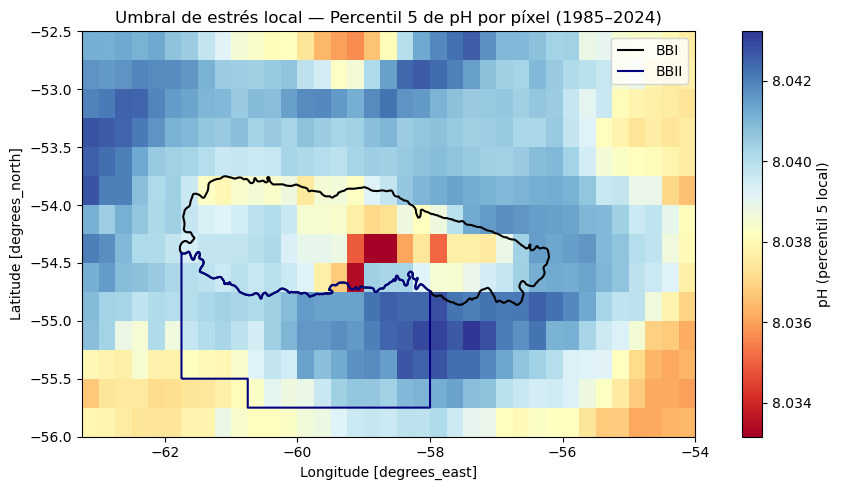

In [3]:
# =============================================================================
# CELDA 3 — Calcular percentil 5 LOCAL (por píxel)
# =============================================================================
 
# Para cada píxel calculamos su propio percentil 5 usando TODA la serie
# histórica (1985–2024). Este es el umbral de estrés local.
#
# ¿Por qué local y no global?
#   Porque distintas partes del BB tienen pH estructuralmente diferente
#   (plateau vs slope, influencia de masas de agua distintas).
#   Un umbral global penalizaría siempre las zonas con pH más bajo,
#   independientemente de si esas zonas están cambiando o no.
#   El umbral local pregunta: "¿este píxel está experimentando condiciones
#   inusualmente bajas para SU propia historia?"
 
print("Calculando percentil 5 local por píxel...")
 
# quantile(0.05) sobre la dimensión temporal → resultado: (latitude, longitude)
ph_p05 = ph.quantile(0.05, dim="time")
 
print(f"Percentil 5 local — rango espacial:")
print(f"  min: {float(ph_p05.min()):.4f}")
print(f"  max: {float(ph_p05.max()):.4f}")
print(f"  mean: {float(ph_p05.mean()):.4f}")
 
# Visualización rápida del umbral espacial
fig, ax = plt.subplots(figsize=(10, 5))
ph_p05.plot(ax=ax, cmap="RdYlBu", cbar_kwargs={"label": "pH (percentil 5 local)"})
 
# Superponer shapes
bbi_shape.boundary.plot(ax=ax, color="black", linewidth=1.5, label="BBI")
bbii_shape.boundary.plot(ax=ax, color="navy", linewidth=1.5, label="BBII")
ax.legend()
ax.set_title("Umbral de estrés local — Percentil 5 de pH por píxel (1985–2024)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "stress_threshold_p05.png"), dpi=150)
plt.show()

Interpretación del mapa de umbral de estrés local
Cada píxel muestra el percentil 5 de su propia serie histórica de pH (1985–2024). Este valor representa el umbral por debajo del cual ese píxel solo estuvo el 5% del tiempo a lo largo de toda su historia — es decir, su "piso histórico".
La variación espacial es pequeña (~0.008 unidades de pH) pero informativa:

Píxeles rojos (~8.033–8.035, centro del área): umbral más bajo → pH históricamente más bajos en esa zona, probablemente por influencia de aguas subsuperficiales más ricas en CO₂ en la zona de confluencia plateau-slope.

Píxeles azules (~8.040–8.042, bordes): umbral más alto → pH históricamente más altos.

Cuando en un mes dado el pH de un píxel cae por debajo de su propio umbral, ese píxel se considera en estrés — está experimentando condiciones de pH inusualmente bajas para su propia historia local.

In [4]:
# =============================================================================
# CELDA 4 — Calcular máscara de estrés mensual
# =============================================================================
 
# Para cada mes y cada píxel: 1 si está en estrés (pH < p05 local), 0 si no
# La comparación es elemento a elemento en la grilla (latitude, longitude)
 
print("Calculando máscara de estrés mensual...")
 
# stress_mask: (time, latitude, longitude) → True/False
stress_mask = ph < ph_p05
 
# Verificación: ¿cuántos píxeles en estrés en total?
n_stress = int(stress_mask.sum())
n_total  = int((~ph.isnull()).sum())
print(f"Meses-píxel en estrés : {n_stress:,} de {n_total:,} ({100*n_stress/n_total:.1f}%)")
print("(debería ser ~5% por construcción del percentil 5)")
 

Calculando máscara de estrés mensual...
Meses-píxel en estrés : 12,432 de 248,640 (5.0%)
(debería ser ~5% por construcción del percentil 5)


In [5]:
# =============================================================================
# CELDA 5 — Serie temporal del área en estrés (panel superior)
# =============================================================================
 
# Para cada mes: porcentaje de píxeles del BB que están en estrés
# Usamos la grilla completa (bbox) — todos los píxeles válidos
 
# Contar píxeles en estrés por mes
n_stress_monthly = stress_mask.sum(dim=["latitude", "longitude"])
 
# Contar píxeles válidos (no-NaN) por mes — puede variar si hay NaN
n_valid_monthly = (~ph.isnull()).sum(dim=["latitude", "longitude"])
 
# Porcentaje de área en estrés por mes
pct_stress_monthly = 100 * n_stress_monthly / n_valid_monthly
 
# Convertir a DataFrame
df_stress_ts = pct_stress_monthly.to_dataframe(name="pct_stress").reset_index()
df_stress_ts["time"] = pd.to_datetime(df_stress_ts["time"])
df_stress_ts["year"] = df_stress_ts["time"].dt.year
 
print("\nSerie temporal de área en estrés:")
print(f"  Meses con estrés > 0%  : {(df_stress_ts['pct_stress'] > 0).sum()}")
print(f"  Meses con estrés > 10% : {(df_stress_ts['pct_stress'] > 10).sum()}")
print(f"  Máximo % área en estrés: {df_stress_ts['pct_stress'].max():.1f}%")
 


Serie temporal de área en estrés:
  Meses con estrés > 0%  : 45
  Meses con estrés > 10% : 32
  Máximo % área en estrés: 100.0%


In [6]:
# =============================================================================
# CELDA 6 — Calcular % de meses en estrés por píxel para cada período
# =============================================================================
 
def stress_pct_period(stress_mask, year_start, year_end):
    """
    Para un período dado, calcula el porcentaje de meses en estrés
    para cada píxel.
 
    Parámetros:
        stress_mask : DataArray booleano (time, lat, lon)
        year_start  : año de inicio del período (inclusive)
        year_end    : año de fin del período (inclusive)
 
    Retorna:
        DataArray (lat, lon) con % de meses en estrés [0–100]
    """
    # Filtrar por período
    mask_period = stress_mask.sel(
        time=stress_mask.time.dt.year.isin(range(year_start, year_end + 1))
    )
 
    # Contar meses en estrés y meses válidos por píxel
    n_stress = mask_period.sum(dim="time")
    n_valid  = mask_period.sizes["time"]  # todos los meses del período
 
    # Porcentaje
    pct = 100 * n_stress / n_valid
 
    return pct
 
 
print("Calculando mapas de estrés por período...")
stress_maps = {}
for label, (y1, y2) in PERIODS.items():
    stress_maps[label] = stress_pct_period(stress_mask, y1, y2)
    pct_mean = float(stress_maps[label].mean())
    print(f"  {label.split(chr(10))[0]}: % medio de estrés = {pct_mean:.2f}%")

Calculando mapas de estrés por período...
  P1 — Baseline: % medio de estrés = 0.00%
  P2 — Transición: % medio de estrés = 0.00%
  P3 — Estrés intenso: % medio de estrés = 20.00%


C:\Users\gisel\AppData\Local\Temp\ipykernel_247616\950513537.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_stress = plt.cm.get_cmap("YlOrRd")  # amarillo → naranja → rojo


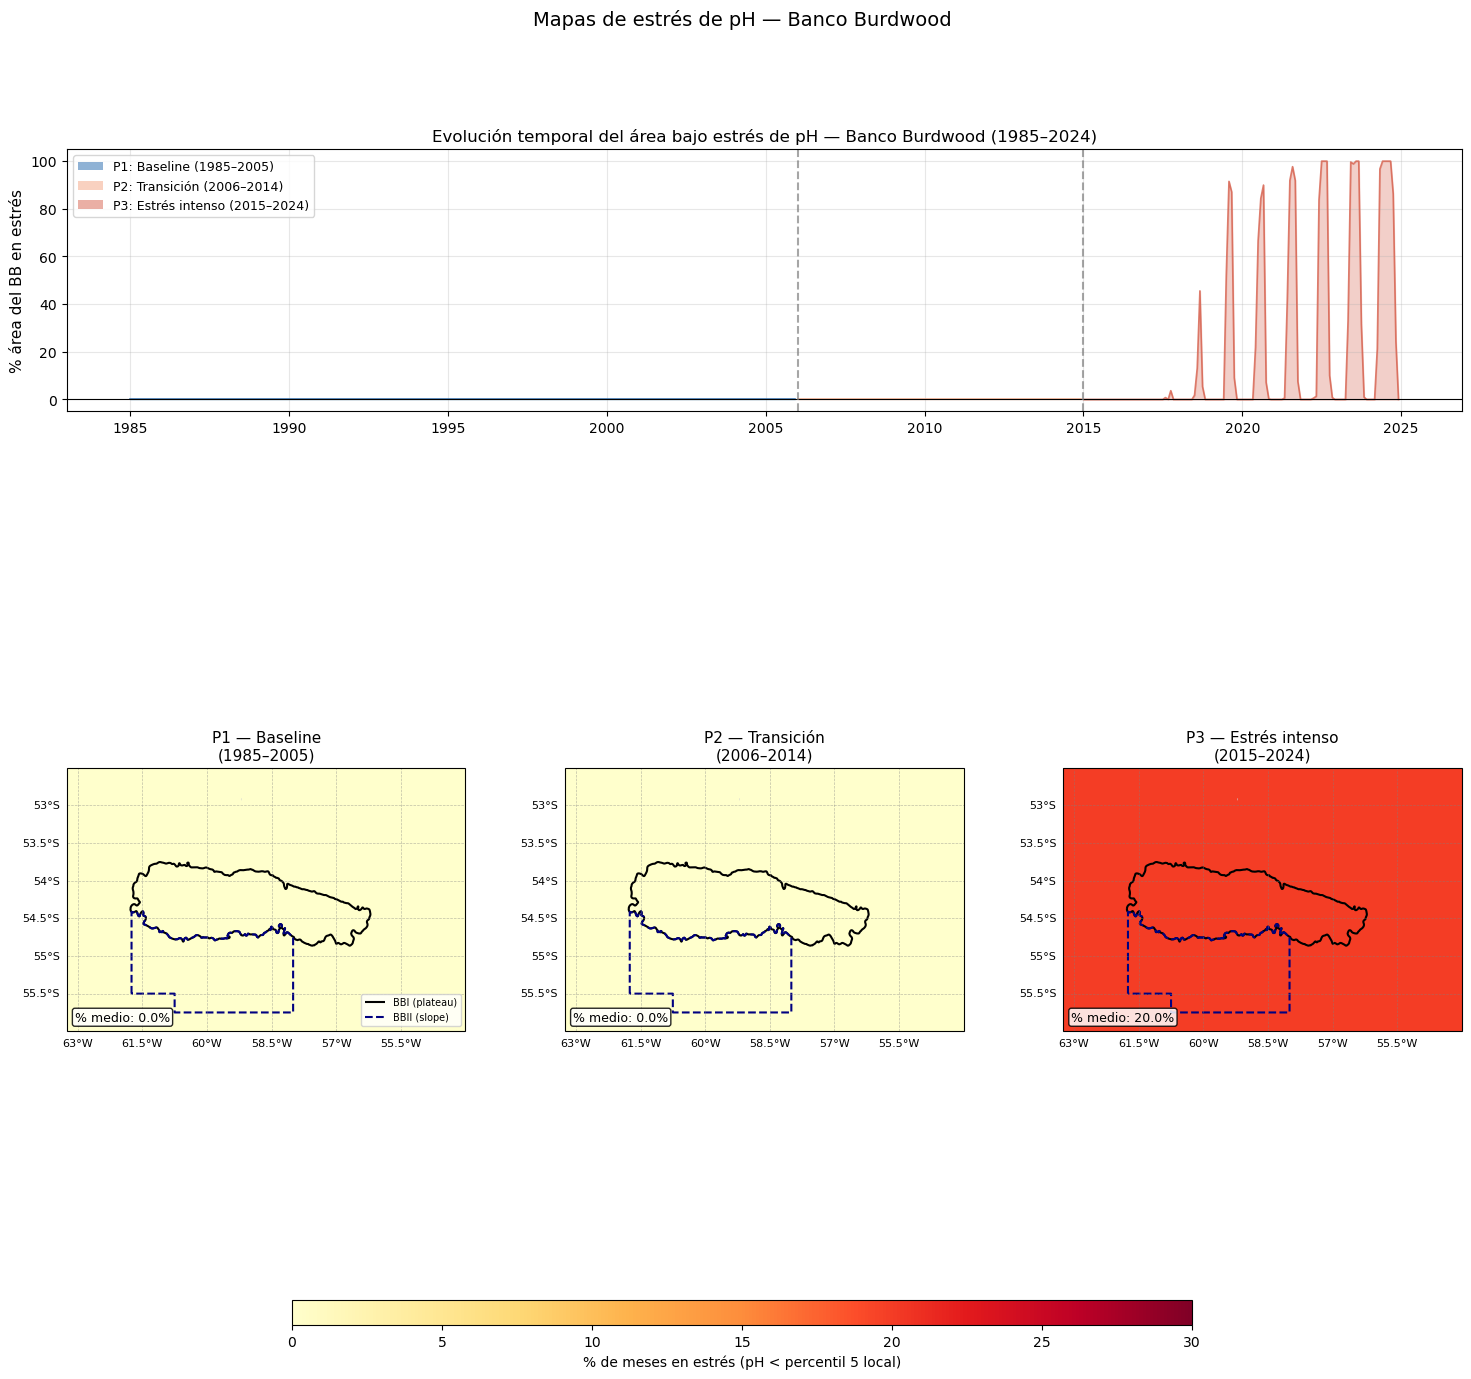

✅ Figura guardada: stress_maps_pH.png


In [7]:
# =============================================================================
# CELDA 7 — Figura principal: panel temporal + tres mapas de estrés
# =============================================================================
 
# Colormap: blanco (0% estrés) → azul claro → verde → rojo (100% estrés)
# Usamos un colormap que resalte los valores altos (estrés severo)
cmap_stress = plt.cm.get_cmap("YlOrRd")  # amarillo → naranja → rojo
vmin, vmax = 0, 30  # % de meses en estrés (ajustar según resultados)
 
proj = ccrs.PlateCarree()
 
fig = plt.figure(figsize=(18, 14))
 
# Layout: 1 panel arriba (serie temporal) + 3 mapas abajo
gs = fig.add_gridspec(2, 3, height_ratios=[1, 2.5], hspace=0.35, wspace=0.25)
 
# -----------------------------------------------------------------------
# Panel superior: serie temporal del % de área en estrés
# -----------------------------------------------------------------------
ax_ts = fig.add_subplot(gs[0, :])  # ocupa las 3 columnas
 
# Colorear por período
period_colors = {"P1": "#2166ac", "P2": "#f4a582", "P3": "#d6604d"}
period_ranges = [
    ("P1", 1985, 2005, "#2166ac"),
    ("P2", 2006, 2014, "#f4a582"),
    ("P3", 2015, 2024, "#d6604d"),
]
 
for pname, y1, y2, pc in period_ranges:
    mask = (df_stress_ts["year"] >= y1) & (df_stress_ts["year"] <= y2)
    ax_ts.fill_between(
        df_stress_ts.loc[mask, "time"],
        df_stress_ts.loc[mask, "pct_stress"],
        alpha=0.3, color=pc
    )
    ax_ts.plot(
        df_stress_ts.loc[mask, "time"],
        df_stress_ts.loc[mask, "pct_stress"],
        color=pc, lw=1.2, alpha=0.8
    )
 
ax_ts.axhline(0, color="black", lw=0.8)
 
# Líneas verticales de separación de períodos
for yr in [2006, 2015]:
    ax_ts.axvline(pd.Timestamp(f"{yr}-01-01"), color="gray",
                  lw=1.5, linestyle="--", alpha=0.7)
 
ax_ts.set_ylabel("% área del BB en estrés", fontsize=11)
ax_ts.set_title("Evolución temporal del área bajo estrés de pH — Banco Burdwood (1985–2024)",
                fontsize=12)
ax_ts.grid(alpha=0.3)
 
# Leyenda de períodos
legend_elements = [
    Patch(facecolor="#2166ac", alpha=0.5, label="P1: Baseline (1985–2005)"),
    Patch(facecolor="#f4a582", alpha=0.5, label="P2: Transición (2006–2014)"),
    Patch(facecolor="#d6604d", alpha=0.5, label="P3: Estrés intenso (2015–2024)"),
]
ax_ts.legend(handles=legend_elements, fontsize=9, loc="upper left")

# -----------------------------------------------------------------------
# Tres mapas de estrés (panel inferior)
# -----------------------------------------------------------------------
period_titles = list(PERIODS.keys())
period_colors_map = ["#2166ac", "#f4a582", "#d6604d"]
 
axes_maps = []
for col, (label, color_p) in enumerate(zip(period_titles, period_colors_map)):
    ax = fig.add_subplot(gs[1, col], projection=proj)
    axes_maps.append(ax)
 
    pct_map = stress_maps[label]
 
    # Plotear mapa de estrés
    im = pct_map.plot(
        ax=ax,
        transform=proj,
        cmap=cmap_stress,
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        add_labels=False,
    )
 
    # Superponer shapes de BBI y BBII
    bbi_shape.boundary.plot(
        ax=ax, transform=proj,
        color="black", linewidth=1.5, label="BBI (plateau)"
    )
    bbii_shape.boundary.plot(
        ax=ax, transform=proj,
        color="navy", linewidth=1.5, linestyle="--", label="BBII (slope)"
    )
 
    # Coastline
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
    # Grilla
    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                      color="gray", alpha=0.5, linestyle="--")
    gl.top_labels    = False
    gl.right_labels  = False
    gl.xlabel_style  = {"size": 8}
    gl.ylabel_style  = {"size": 8}
 
    # % medio de estrés en el área
    pct_mean = float(pct_map.mean())
    ax.text(0.02, 0.04, f"% medio: {pct_mean:.1f}%",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85))
 
    ax.set_title(label, fontsize=11, pad=6)
 
    if col == 0:
        ax.legend(loc="lower right", fontsize=7)
 
# Colorbar compartida para los tres mapas
cbar_ax = fig.add_axes([0.25, 0.04, 0.5, 0.018])
sm = plt.cm.ScalarMappable(cmap=cmap_stress,
                            norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("% de meses en estrés (pH < percentil 5 local)", fontsize=10)
 
plt.suptitle("Mapas de estrés de pH — Banco Burdwood", fontsize=14, y=0.98)
 
plt.savefig(os.path.join(FIGURES_DIR, "stress_maps_pH.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figura guardada: stress_maps_pH.png")
 
 

In [8]:
# =============================================================================
# CELDA 8 — Resumen cuantitativo para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN MAPAS DE ESTRÉS — PARA EL PAPER")
print("="*60)
 
for label, (y1, y2) in PERIODS.items():
    pct_map   = stress_maps[label]
    n_months  = (y2 - y1 + 1) * 12
 
    # % medio de estrés sobre toda la grilla
    pct_mean  = float(pct_map.mean())
 
    # % de píxeles con al menos algún estrés (> 0%)
    pct_any   = float((pct_map > 0).mean() * 100)
 
    # % de píxeles con estrés severo (> 10% de meses)
    pct_sev   = float((pct_map > 10).mean() * 100)
 
    period_label = label.replace("\n", " ")
    print(f"\n  {period_label}")
    print(f"    N meses del período            : {n_months}")
    print(f"    % medio de estrés (grilla)     : {pct_mean:.2f}%")
    print(f"    % píxeles con algún estrés     : {pct_any:.1f}%")
    print(f"    % píxeles con estrés severo    : {pct_sev:.1f}%  (>10% meses)")
 


  RESUMEN MAPAS DE ESTRÉS — PARA EL PAPER

  P1 — Baseline (1985–2005)
    N meses del período            : 252
    % medio de estrés (grilla)     : 0.00%
    % píxeles con algún estrés     : 0.0%
    % píxeles con estrés severo    : 0.0%  (>10% meses)

  P2 — Transición (2006–2014)
    N meses del período            : 108
    % medio de estrés (grilla)     : 0.00%
    % píxeles con algún estrés     : 0.0%
    % píxeles con estrés severo    : 0.0%  (>10% meses)

  P3 — Estrés intenso (2015–2024)
    N meses del período            : 120
    % medio de estrés (grilla)     : 20.00%
    % píxeles con algún estrés     : 100.0%
    % píxeles con estrés severo    : 100.0%  (>10% meses)


In [9]:
# Verificación: distribución temporal del estrés
print("Meses con algún píxel en estrés:")
df_check = df_stress_ts[df_stress_ts["pct_stress"] > 0][["time", "pct_stress"]]
print(df_check.to_string())

# Cuándo ocurrió el primer mes de estrés
primer_estres = df_stress_ts[df_stress_ts["pct_stress"] > 0]["time"].min()
print(f"\nPrimer mes con estrés: {primer_estres.strftime('%Y-%m')}")

Meses con algún píxel en estrés:
          time  pct_stress
391 2017-08-01    0.772201
393 2017-10-01    3.667954
402 2018-07-01    1.737452
403 2018-08-01   13.127413
404 2018-09-01   45.559846
405 2018-10-01    5.405405
414 2019-07-01   52.123552
415 2019-08-01   91.505792
416 2019-09-01   87.065637
417 2019-10-01    9.073359
425 2020-06-01   21.814672
426 2020-07-01   66.602317
427 2020-08-01   84.362934
428 2020-09-01   89.961390
429 2020-10-01    7.142857
430 2020-11-01    0.193050
436 2021-05-01    0.579151
437 2021-06-01   41.312741
438 2021-07-01   91.891892
439 2021-08-01   97.683398
440 2021-09-01   91.891892
441 2021-10-01    7.528958
447 2022-04-01    0.579151
448 2022-05-01    1.351351
449 2022-06-01   83.783784
450 2022-07-01  100.000000
451 2022-08-01  100.000000
452 2022-09-01  100.000000
453 2022-10-01   10.038610
454 2022-11-01    0.772201
460 2023-05-01   33.011583
461 2023-06-01   99.613900
462 2023-07-01   98.841699
463 2023-08-01  100.000000
464 2023-09-01  100.00

## Lo que revelan los datos
El estrés tiene una estacionalidad muy marcada
Todos los eventos de estrés ocurren entre abril y noviembre, con picos en julio–septiembre (invierno austral). Esto tiene mucho sentido oceanográfico: en invierno la mezcla vertical es más profunda, trae agua más rica en CO₂ a la superficie → pH baja. Además la productividad primaria es mínima en invierno → menos consumo de CO₂ por fotosíntesis → pH más bajo.
La intensificación es progresiva y muy clara:

2017: eventos aislados, < 4% del área
2018: primer evento severo (45% en septiembre)
2019–2021: estrés masivo, > 90% del área en pico invernal
2022–2024: prácticamente 100% del área en estrés durante julio–septiembre

El primer mes de estrés fue agosto 2017 → esto es más reciente que el 2015 que habías visto antes. Probablemente en tu análisis anterior usabas un umbral diferente.

In [10]:
# Figura 2: pH real del peor trimestre invernal por período
# =============================================================================
# Idea:
#   En lugar de mostrar si un píxel "está o no en estrés" (binario),
#   mostramos el pH REAL promedio del trimestre invernal (jul-sep) de
#   cada período. Así vemos:
#     1. Cuánto bajó el pH en el peor momento estacional de cada período
#     2. Si hay gradientes espaciales en la intensidad del mínimo invernal
#   Superponemos la isolínea del percentil 5 local como contorno para
#   mostrar visualmente qué zonas están por debajo del umbral de estrés.
# =============================================================================

In [10]:
# =============================================================================
# CELDA A — Calcular pH promedio del trimestre invernal por período
# =============================================================================
 
def winter_mean_ph(ph, year_start, year_end, months=[7, 8, 9]):
    """
    Calcula el pH promedio del trimestre invernal (jul-sep por defecto)
    para un período dado.
 
    Parámetros:
        ph         : DataArray (time, latitude, longitude)
        year_start : año de inicio (inclusive)
        year_end   : año de fin (inclusive)
        months     : meses a incluir (default: julio=7, agosto=8, sep=9)
 
    Retorna:
        DataArray (latitude, longitude) con pH medio invernal del período
    """
    # Filtrar por período y meses invernales
    ph_period = ph.sel(
        time=ph.time.dt.year.isin(range(year_start, year_end + 1))
    )
    ph_winter = ph_period.sel(
        time=ph_period.time.dt.month.isin(months)
    )
 
    # Promedio temporal → mapa 2D
    return ph_winter.mean(dim="time")
 
 
print("Calculando pH invernal por período...")
 
winter_maps = {}
for label, (y1, y2) in PERIODS.items():
    winter_maps[label] = winter_mean_ph(ph, y1, y2)
    ph_mean = float(winter_maps[label].mean())
    ph_min  = float(winter_maps[label].min())
    ph_max  = float(winter_maps[label].max())
    print(f"\n  {label.split(chr(10))[0]}:")
    print(f"    pH medio invernal : {ph_mean:.4f}")
    print(f"    pH mínimo         : {ph_min:.4f}")
    print(f"    pH máximo         : {ph_max:.4f}")
 

Calculando pH invernal por período...

  P1 — Baseline:
    pH medio invernal : 8.0797
    pH mínimo         : 8.0759
    pH máximo         : 8.0841

  P2 — Transición:
    pH medio invernal : 8.0579
    pH mínimo         : 8.0540
    pH máximo         : 8.0623

  P3 — Estrés intenso:
    pH medio invernal : 8.0379
    pH mínimo         : 8.0316
    pH máximo         : 8.0409


Escala de color compartida: 8.0310 – 8.0850


C:\Users\gisel\AppData\Local\Temp\ipykernel_247616\4224613856.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


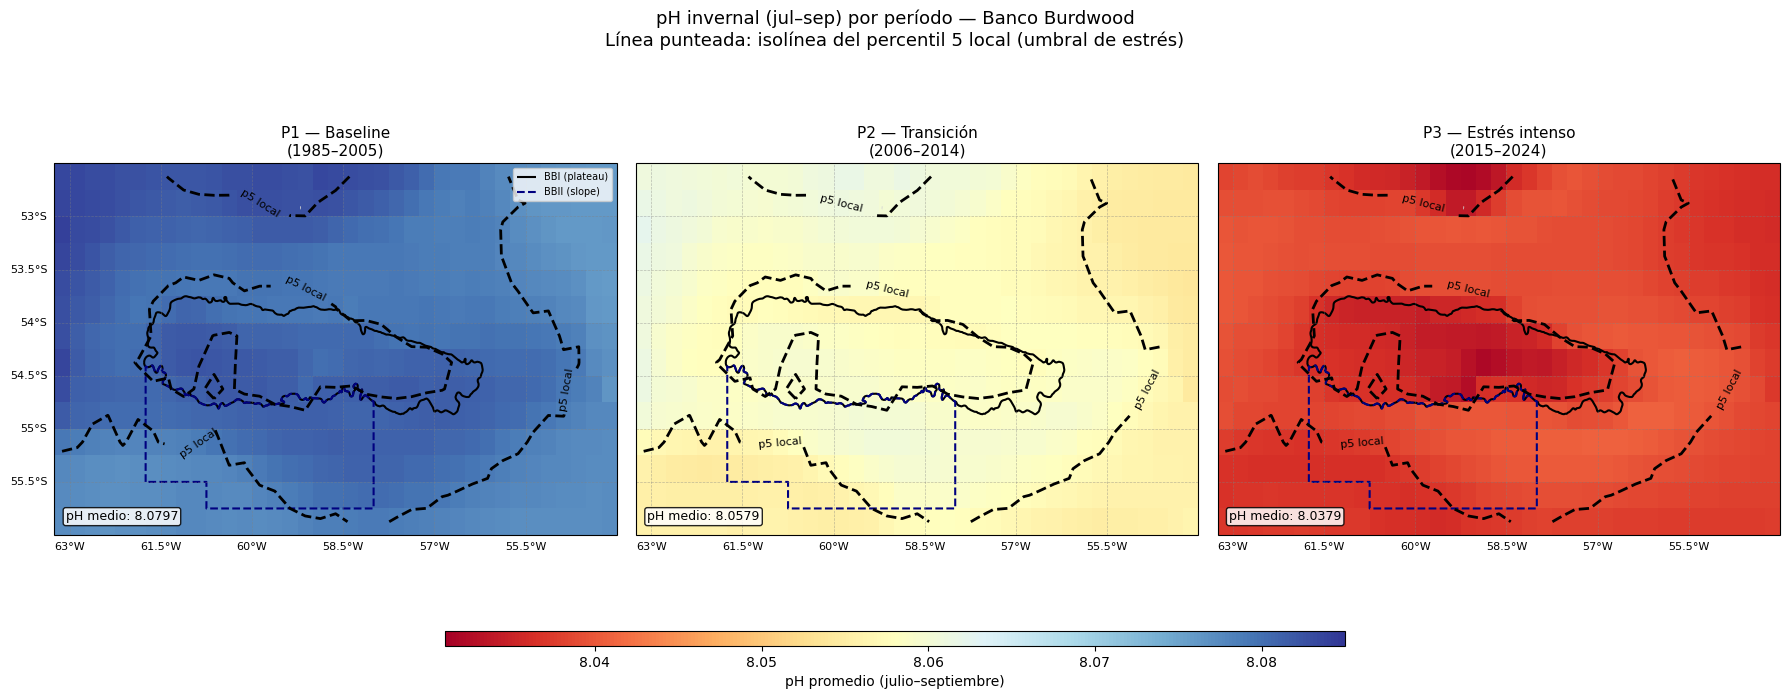

✅ Figura guardada: winter_ph_maps.png


In [11]:
# =============================================================================
# CELDA B — Figura: tres mapas de pH invernal + isolínea del percentil 5
# =============================================================================
 
# Escala de color compartida para los tres mapas
# Usamos el mínimo global de P3 y el máximo global de P1 para que
# los tres mapas sean directamente comparables entre sí
vmin_ph = min(float(m.min()) for m in winter_maps.values())
vmax_ph = max(float(m.max()) for m in winter_maps.values())
 
# Redondear para escala limpia
vmin_ph = np.floor(vmin_ph * 1000) / 1000
vmax_ph = np.ceil(vmax_ph  * 1000) / 1000
 
print(f"Escala de color compartida: {vmin_ph:.4f} – {vmax_ph:.4f}")
 
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={"projection": proj}
)
 
period_labels = list(PERIODS.keys())
 
for col, (label, ax) in enumerate(zip(period_labels, axes)):
    y1, y2 = list(PERIODS.values())[col]
    ph_map  = winter_maps[label]
 
    # --- Mapa de pH invernal ---
    im = ph_map.plot(
        ax=ax,
        transform=proj,
        cmap="RdYlBu",        # rojo=bajo, azul=alto (igual que mapa de umbral)
        vmin=vmin_ph,
        vmax=vmax_ph,
        add_colorbar=False,
        add_labels=False,
    )
 
    # --- Isolínea del percentil 5 local ---
    # Muestra el contorno donde el pH invernal iguala el umbral de estrés
    # Píxeles por DEBAJO de esta línea están en estrés en ese trimestre
    lons = ph_map.longitude.values
    lats = ph_map.latitude.values
    LON, LAT = np.meshgrid(lons, lats)
 
    contour = ax.contour(
        LON, LAT, ph_p05.values,
        levels=[float(ph_p05.mean())],  # isolínea en el percentil 5 medio
        colors=["black"],
        linewidths=[2],
        linestyles=["--"],
        transform=proj,
        zorder=5
    )
    ax.clabel(contour, fmt="p5 local", fontsize=8, colors="black")
 
    # --- Shapes BBI y BBII ---
    bbi_shape.boundary.plot(
        ax=ax, transform=proj,
        color="black", linewidth=1.5, label="BBI (plateau)"
    )
    bbii_shape.boundary.plot(
        ax=ax, transform=proj,
        color="navy", linewidth=1.5, linestyle="--", label="BBII (slope)"
    )
 
    # --- Coastline y land ---
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)
 
    # --- Grilla ---
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5,
        color="gray", alpha=0.5, linestyle="--"
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    if col > 0:
        gl.left_labels = False
 
    # --- Anotación del pH medio invernal ---
    ax.text(
        0.02, 0.04,
        f"pH medio: {float(ph_map.mean()):.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85)
    )
 
    ax.set_title(label, fontsize=11, pad=6)
 
    if col == 0:
        ax.legend(loc="upper right", fontsize=7)
 
# --- Colorbar compartida ---
cbar_ax = fig.add_axes([0.25, -0.04, 0.5, 0.025])
sm = plt.cm.ScalarMappable(
    cmap="RdYlBu",
    norm=mcolors.Normalize(vmin=vmin_ph, vmax=vmax_ph)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("pH promedio (julio–septiembre)", fontsize=10)
 
plt.suptitle(
    "pH invernal (jul–sep) por período — Banco Burdwood\n"
    "Línea punteada: isolínea del percentil 5 local (umbral de estrés)",
    fontsize=13, y=1.02
)
 
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "winter_ph_maps.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Figura guardada: winter_ph_maps.png")

In [12]:
# =============================================================================
# CELDA C — Resumen cuantitativo para el paper
# =============================================================================
 
print("\n" + "="*60)
print("  RESUMEN pH INVERNAL — PARA EL PAPER")
print("="*60)
 
p5_mean = float(ph_p05.mean())
 
for label, (y1, y2) in PERIODS.items():
    ph_map   = winter_maps[label]
    ph_mean  = float(ph_map.mean())
    ph_min   = float(ph_map.min())
 
    # % de píxeles por debajo del umbral de estrés en ese trimestre
    pct_below = float((ph_map < ph_p05).mean() * 100)
 
    period_label = label.replace("\n", " ")
    print(f"\n  {period_label}")
    print(f"    pH medio invernal        : {ph_mean:.4f}")
    print(f"    pH mínimo invernal       : {ph_min:.4f}")
    print(f"    Umbral p5 medio          : {p5_mean:.4f}")
    print(f"    Diferencia media–umbral  : {ph_mean - p5_mean:.4f}")
    print(f"    % píxeles bajo umbral    : {pct_below:.1f}%")
 


  RESUMEN pH INVERNAL — PARA EL PAPER

  P1 — Baseline (1985–2005)
    pH medio invernal        : 8.0797
    pH mínimo invernal       : 8.0759
    Umbral p5 medio          : 8.0398
    Diferencia media–umbral  : 0.0399
    % píxeles bajo umbral    : 0.0%

  P2 — Transición (2006–2014)
    pH medio invernal        : 8.0579
    pH mínimo invernal       : 8.0540
    Umbral p5 medio          : 8.0398
    Diferencia media–umbral  : 0.0181
    % píxeles bajo umbral    : 0.0%

  P3 — Estrés intenso (2015–2024)
    pH medio invernal        : 8.0379
    pH mínimo invernal       : 8.0316
    Umbral p5 medio          : 8.0398
    Diferencia media–umbral  : -0.0019
    % píxeles bajo umbral    : 94.8%


Escala de color ajustada: 8.0349 – 8.0827


C:\Users\gisel\AppData\Local\Temp\ipykernel_247616\2160139411.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


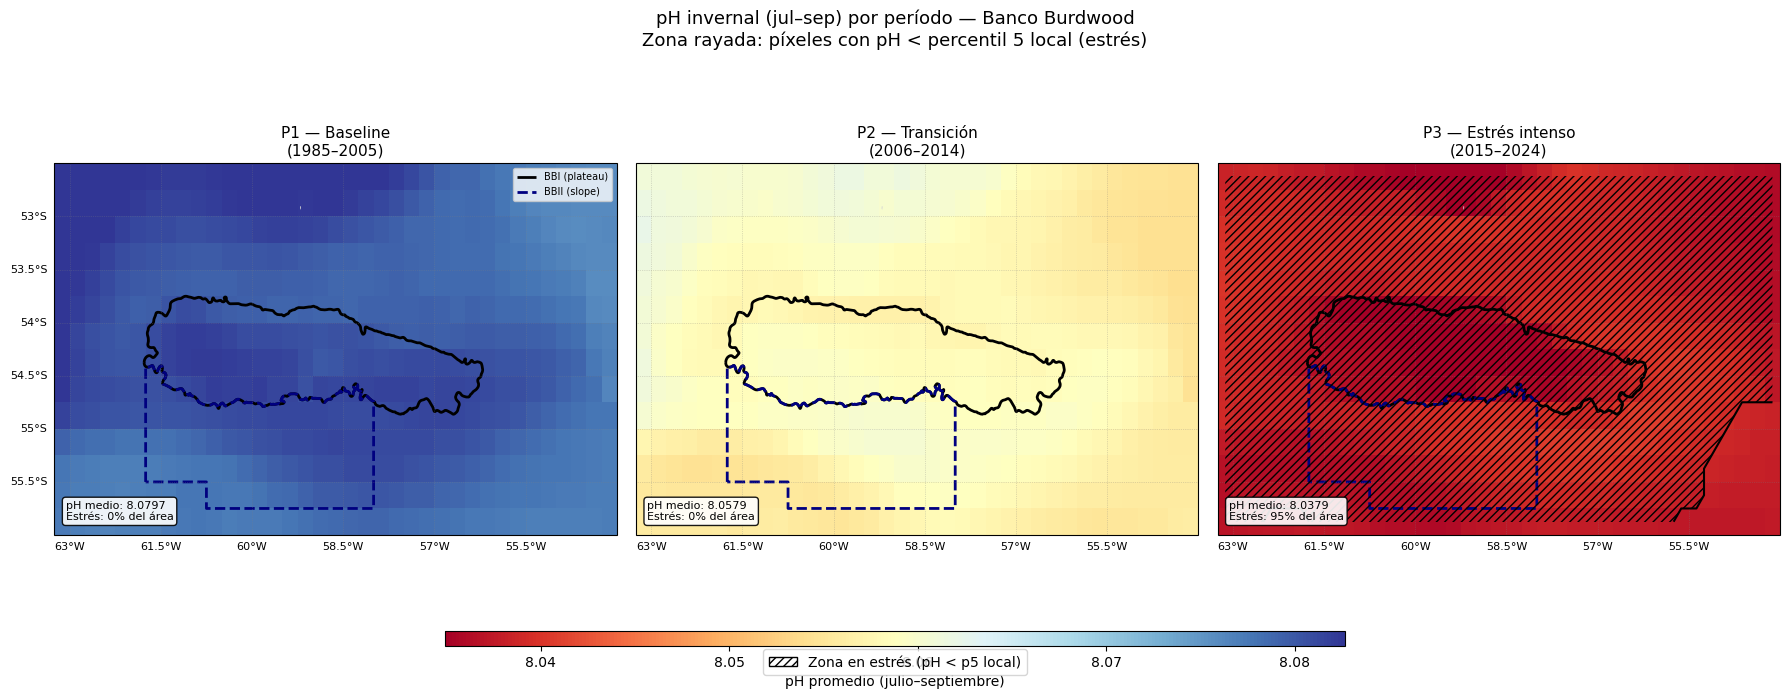

✅ Figura guardada: winter_ph_maps_v2.png


In [13]:
# =============================================================================
# CELDA B (versión 2) — Mapas de pH invernal con zona sombreada de estrés
# =============================================================================
# Cambios respecto a la versión anterior:
#   1. La isolínea se reemplaza por una ZONA SOMBREADA que muestra
#      exactamente qué píxeles tienen pH invernal < percentil 5 LOCAL
#      (comparación píxel a píxel, no un valor promedio global)
#   2. Se achica el rango de color para aumentar el contraste espacial
# =============================================================================

import matplotlib.patches as mpatches

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={"projection": proj}
)

# --- Rango de color ajustado ---
# Usamos percentiles 2-98 de todos los valores invernales para que
# el contraste se concentre donde hay variación real, evitando que
# outliers extremos compriman la escala
all_vals = np.concatenate([m.values.ravel() for m in winter_maps.values()])
all_vals = all_vals[~np.isnan(all_vals)]
vmin_ph  = np.percentile(all_vals, 2)
vmax_ph  = np.percentile(all_vals, 98)

print(f"Escala de color ajustada: {vmin_ph:.4f} – {vmax_ph:.4f}")

period_labels = list(PERIODS.keys())

for col, (label, ax) in enumerate(zip(period_labels, axes)):
    y1, y2   = list(PERIODS.values())[col]
    ph_map   = winter_maps[label]

    # --- Mapa de pH invernal ---
    im = ph_map.plot(
        ax=ax,
        transform=proj,
        cmap="RdYlBu",
        vmin=vmin_ph,
        vmax=vmax_ph,
        add_colorbar=False,
        add_labels=False,
    )

    # --- Zona sombreada de estrés ---
    # Máscara píxel a píxel: True donde pH invernal < percentil 5 LOCAL
    # Esto es metodológicamente correcto — cada píxel se compara con
    # su propio umbral histórico, no con un valor global
    stress_zone = ph_map < ph_p05

    lons = ph_map.longitude.values
    lats = ph_map.latitude.values
    LON, LAT = np.meshgrid(lons, lats)

    # Sombrear con hatching (rayado diagonal) las zonas en estrés
    ax.contourf(
        LON, LAT, stress_zone.values.astype(float),
        levels=[0.5, 1.5],
        hatches=["////"],
        colors="none",
        transform=proj,
        zorder=4
    )

    # Contorno del borde de la zona en estrés
    ax.contour(
        LON, LAT, stress_zone.values.astype(float),
        levels=[0.5],
        colors=["black"],
        linewidths=[1.5],
        transform=proj,
        zorder=5
    )

    # --- Shapes BBI y BBII ---
    bbi_shape.boundary.plot(
        ax=ax, transform=proj,
        color="black", linewidth=2, label="BBI (plateau)"
    )
    bbii_shape.boundary.plot(
        ax=ax, transform=proj,
        color="navy", linewidth=2, linestyle="--", label="BBII (slope)"
    )

    # --- Coastline y land ---
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=6)

    # --- Grilla ---
    gl = ax.gridlines(
        draw_labels=True, linewidth=0.5,
        color="gray", alpha=0.5, linestyle=":"
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    if col > 0:
        gl.left_labels = False

    # --- Anotación: pH medio y % en estrés ---
    ph_mean    = float(ph_map.mean())
    pct_stress = float(stress_zone.mean() * 100)

    ax.text(
        0.02, 0.04,
        f"pH medio: {ph_mean:.4f}\nEstrés: {pct_stress:.0f}% del área",
        transform=ax.transAxes, fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
        zorder=7
    )

    ax.set_title(label, fontsize=11, pad=6)

    if col == 0:
        ax.legend(loc="upper right", fontsize=7)

# --- Colorbar compartida ---
cbar_ax = fig.add_axes([0.25, -0.04, 0.5, 0.025])
sm = plt.cm.ScalarMappable(
    cmap="RdYlBu",
    norm=mcolors.Normalize(vmin=vmin_ph, vmax=vmax_ph)
)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("pH promedio (julio–septiembre)", fontsize=10)

# --- Leyenda zona sombreada ---
stress_patch = mpatches.Patch(
    facecolor="none", edgecolor="black",
    hatch="////", label="Zona en estrés (pH < p5 local)"
)
fig.legend(
    handles=[stress_patch],
    loc="lower center", bbox_to_anchor=(0.5, -0.10),
    fontsize=10, frameon=True
)

plt.suptitle(
    "pH invernal (jul–sep) por período — Banco Burdwood\n"
    "Zona rayada: píxeles con pH < percentil 5 local (estrés)",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "winter_ph_maps_v2.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Figura guardada: winter_ph_maps_v2.png")

Anomalías respecto al baseline (P1):
  P2 − P1: media=-0.0218, min=-0.0232, max=-0.0205
  P3 − P1: media=-0.0417, min=-0.0510, max=-0.0390

Escala anomalías (simétrica): ±0.0520


C:\Users\gisel\AppData\Local\Temp\ipykernel_247616\3931448642.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


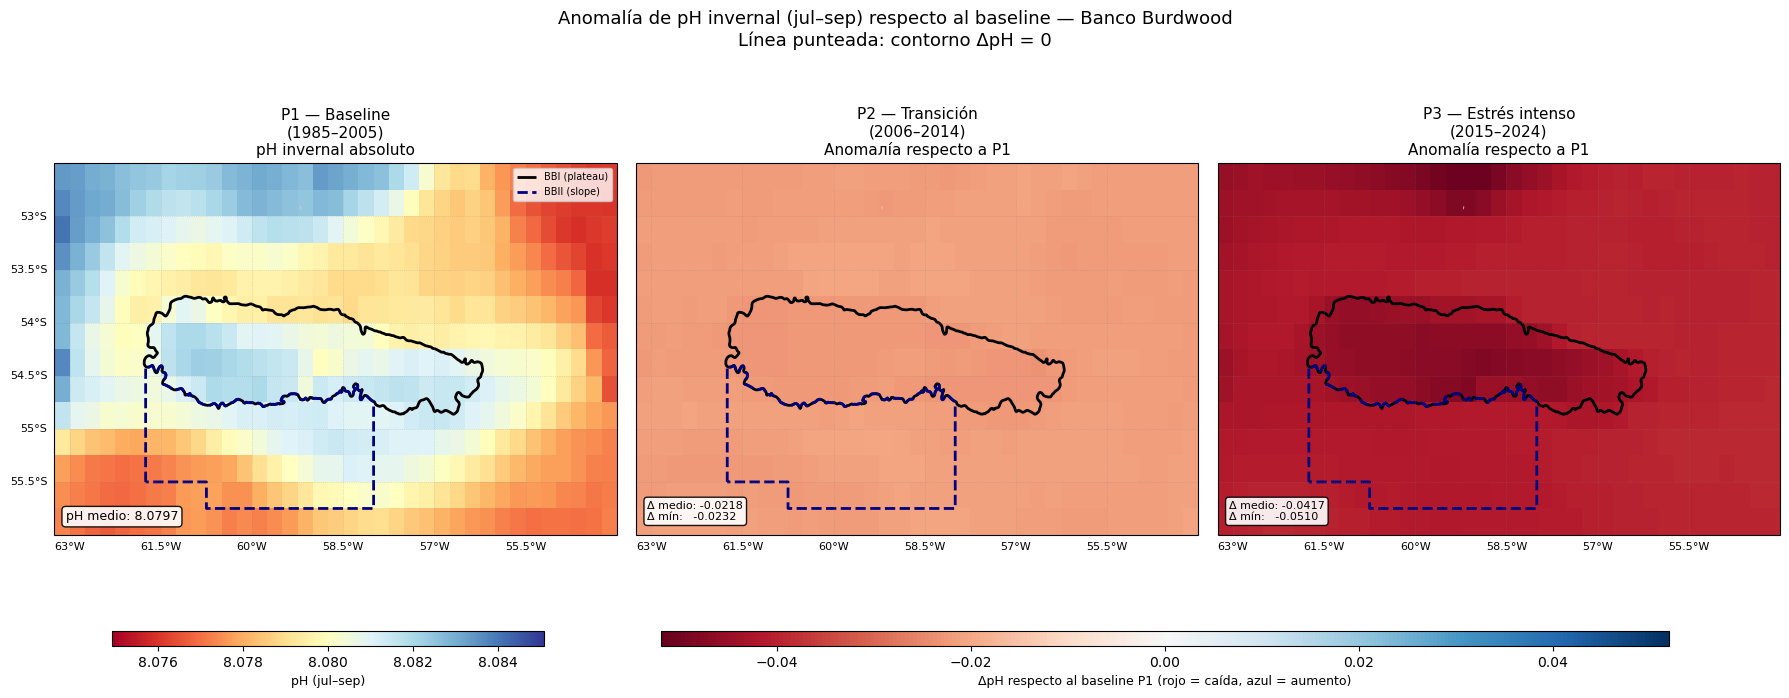

✅ Figura guardada: winter_ph_anomaly_maps.png

  RESUMEN ANOMALÍAS pH INVERNAL — PARA EL PAPER

  Baseline P1 (1985–2005):
    pH medio invernal : 8.0797
    pH mínimo         : 8.0759

  P2 (2006–2014):
    Δ pH medio        : -0.0218
    Δ pH mínimo       : -0.0232
    Δ pH máximo       : -0.0205
    % área con caída  : 100.0%

  P3 (2015–2024):
    Δ pH medio        : -0.0417
    Δ pH mínimo       : -0.0510
    Δ pH máximo       : -0.0390
    % área con caída  : 100.0%


In [16]:
# =============================================================================
# CELDA B (versión 3) — Mapas de anomalía de pH invernal respecto al baseline
# =============================================================================
# En lugar de pH absoluto, mostramos la DIFERENCIA respecto al período
# baseline (P1: 1985-2005):
#   Anomalía P2 = pH invernal P2 − pH invernal P1
#   Anomalía P3 = pH invernal P3 − pH invernal P1
#
# Ventajas:
#   - Muestra directamente la señal del cambio: cuánto bajó el pH
#   - El colormap divergente (azul=sin cambio, rojo=caída) es intuitivo
#   - Permite ver si hay gradientes espaciales en la intensidad del cambio
#   - No necesita zona sombreada — el color cuenta la historia
#
# Layout: 3 paneles
#   Izquierda  : pH absoluto de P1 (baseline — referencia)
#   Centro     : anomalía P2 − P1
#   Derecha    : anomalía P3 − P1
# =============================================================================

import matplotlib.patches as mpatches

# --- Calcular anomalías ---
ph_P1 = winter_maps[list(PERIODS.keys())[0]]  # baseline
ph_P2 = winter_maps[list(PERIODS.keys())[1]]
ph_P3 = winter_maps[list(PERIODS.keys())[2]]

anom_P2 = ph_P2 - ph_P1  # anomalía transición
anom_P3 = ph_P3 - ph_P1  # anomalía estrés intenso

print("Anomalías respecto al baseline (P1):")
print(f"  P2 − P1: media={float(anom_P2.mean()):.4f}, min={float(anom_P2.min()):.4f}, max={float(anom_P2.max()):.4f}")
print(f"  P3 − P1: media={float(anom_P3.mean()):.4f}, min={float(anom_P3.min()):.4f}, max={float(anom_P3.max()):.4f}")

# --- Escala de color para el baseline (pH absoluto) ---
vmin_abs = float(ph_P1.min()) - 0.001
vmax_abs = float(ph_P1.max()) + 0.001

# --- Escala de color para anomalías (simétrica alrededor de 0) ---
# Usamos el máximo absoluto de ambas anomalías para escala simétrica
anom_max = max(abs(float(anom_P2.min())), abs(float(anom_P2.max())),
               abs(float(anom_P3.min())), abs(float(anom_P3.max())))
anom_max = np.ceil(anom_max * 1000) / 1000  # redondear hacia arriba

print(f"\nEscala anomalías (simétrica): ±{anom_max:.4f}")

# --- Figura ---
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={"projection": proj}
)

# -----------------------------------------------------------------------
# Panel 1: pH absoluto del baseline (P1)
# -----------------------------------------------------------------------
ax = axes[0]

im_abs = ph_P1.plot(
    ax=ax,
    transform=proj,
    cmap="RdYlBu",
    vmin=vmin_abs,
    vmax=vmax_abs,
    add_colorbar=False,
    add_labels=False,
)

bbi_shape.boundary.plot(ax=ax, transform=proj,
                         color="black", linewidth=2, label="BBI (plateau)")
bbii_shape.boundary.plot(ax=ax, transform=proj,
                          color="navy", linewidth=2, linestyle="--", label="BBII (slope)")
ax.coastlines(resolution="10m", color="black", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                   color="gray", alpha=0.4, linestyle=":")
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}

ax.text(0.02, 0.04, f"pH medio: {float(ph_P1.mean()):.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)

ax.set_title("P1 — Baseline\n(1985–2005)\npH invernal absoluto", fontsize=11, pad=6)
ax.legend(loc="upper right", fontsize=7)

# Colorbar para el baseline
cbar_ax1 = fig.add_axes([0.065, -0.04, 0.24, 0.025])
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu",
                              norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
sm1.set_array([])
cb1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cb1.set_label("pH (jul–sep)", fontsize=9)

# -----------------------------------------------------------------------
# Paneles 2 y 3: anomalías P2-P1 y P3-P1
# -----------------------------------------------------------------------
anom_data = [
    (anom_P2, "P2 — Transición\n(2006–2014)\nAnomалía respecto a P1"),
    (anom_P3, "P3 — Estrés intenso\n(2015–2024)\nAnomalía respecto a P1"),
]

for col, (anom_map, title) in enumerate(anom_data):
    ax = axes[col + 1]

    im_anom = anom_map.plot(
        ax=ax,
        transform=proj,
        cmap="RdBu",       # rojo=caída de pH, azul=aumento
        vmin=-anom_max,
        vmax=anom_max,
        add_colorbar=False,
        add_labels=False,
    )

    # Contorno en cero — separa zonas con caída de las sin cambio
    lons = anom_map.longitude.values
    lats = anom_map.latitude.values
    LON, LAT = np.meshgrid(lons, lats)

    ax.contour(
        LON, LAT, anom_map.values,
        levels=[0],
        colors=["black"],
        linewidths=[1.2],
        linestyles=["--"],
        transform=proj,
        zorder=4
    )

    bbi_shape.boundary.plot(ax=ax, transform=proj,
                             color="black", linewidth=2)
    bbii_shape.boundary.plot(ax=ax, transform=proj,
                              color="navy", linewidth=2, linestyle="--")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                       color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False; gl.left_labels = False
    gl.xlabel_style = {"size": 8}

    anom_mean = float(anom_map.mean())
    anom_min  = float(anom_map.min())
    ax.text(0.02, 0.04,
            f"Δ medio: {anom_mean:.4f}\nΔ mín:   {anom_min:.4f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)

    ax.set_title(title, fontsize=11, pad=6)

# Colorbar compartida para anomalías
cbar_ax2 = fig.add_axes([0.37, -0.04, 0.56, 0.025])
sm2 = plt.cm.ScalarMappable(cmap="RdBu",
                              norm=mcolors.Normalize(vmin=-anom_max, vmax=anom_max))
sm2.set_array([])
cb2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cb2.set_label("ΔpH respecto al baseline P1 (rojo = caída, azul = aumento)", fontsize=9)

plt.suptitle(
    "Anomalía de pH invernal (jul–sep) respecto al baseline — Banco Burdwood\n"
    "Línea punteada: contorno ΔpH = 0",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "winter_ph_anomaly_maps.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Figura guardada: winter_ph_anomaly_maps.png")


# =============================================================================
# CELDA C (actualizada) — Resumen para el paper
# =============================================================================

print("\n" + "="*60)
print("  RESUMEN ANOMALÍAS pH INVERNAL — PARA EL PAPER")
print("="*60)
print(f"\n  Baseline P1 (1985–2005):")
print(f"    pH medio invernal : {float(ph_P1.mean()):.4f}")
print(f"    pH mínimo         : {float(ph_P1.min()):.4f}")

for anom_map, label in [(anom_P2, "P2 (2006–2014)"), (anom_P3, "P3 (2015–2024)")]:
    print(f"\n  {label}:")
    print(f"    Δ pH medio        : {float(anom_map.mean()):.4f}")
    print(f"    Δ pH mínimo       : {float(anom_map.min()):.4f}")
    print(f"    Δ pH máximo       : {float(anom_map.max()):.4f}")
    pct_negative = float((anom_map < 0).mean() * 100)
    print(f"    % área con caída  : {pct_negative:.1f}%")

Escala anomalías ajustada: -0.0520 – 0.0000


C:\Users\gisel\AppData\Local\Temp\ipykernel_247616\451216775.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


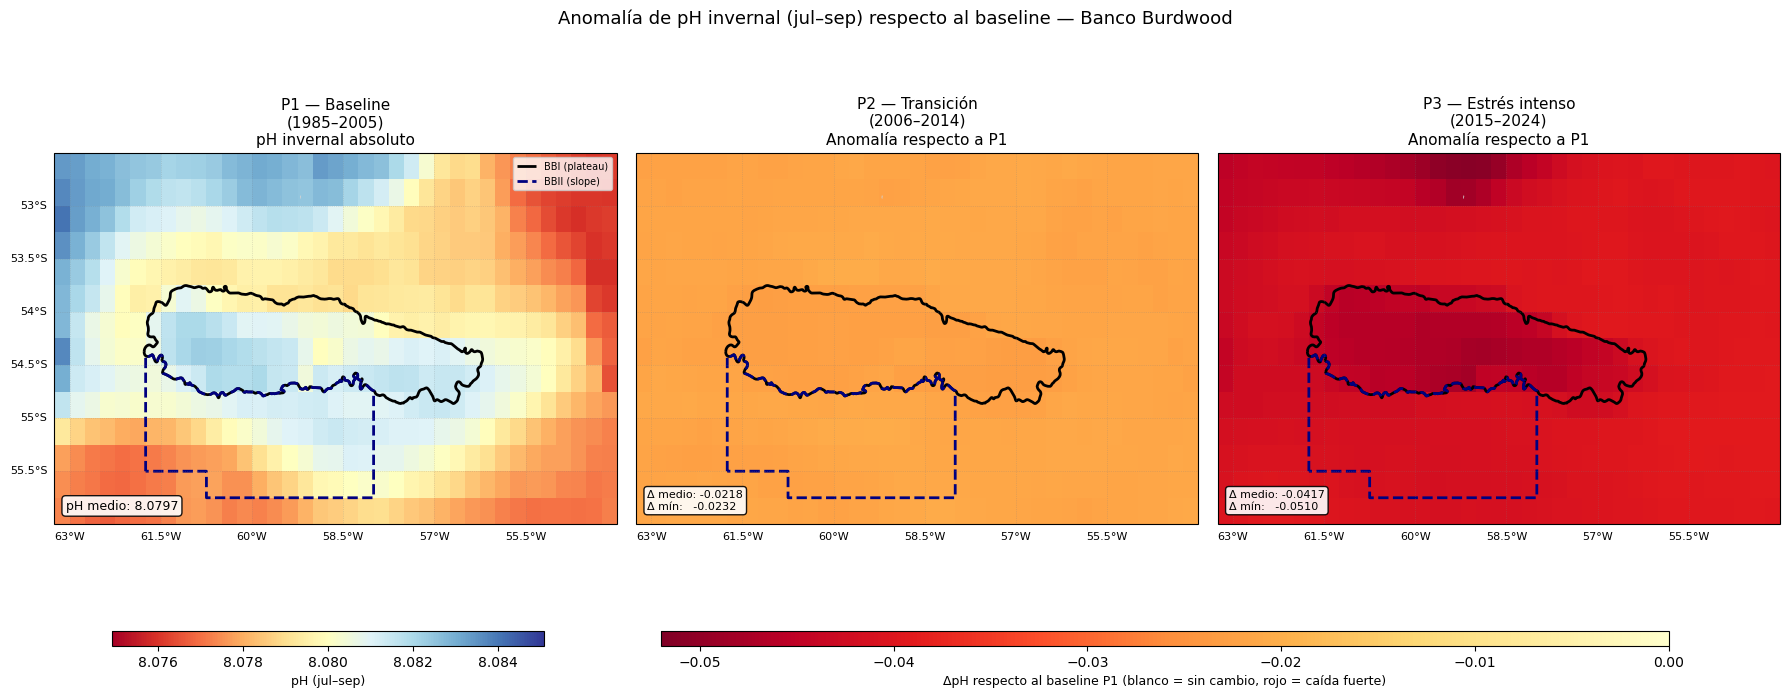

✅ Figura guardada: winter_ph_anomaly_maps_v2.png


In [17]:
# =============================================================================
# CELDA B (versión 4) — Anomalías con escala enfocada en el rango negativo
# =============================================================================
# Cambio respecto a v3:
#   La escala de color ya no es simétrica (±max) sino que se enfoca
#   en el rango negativo real de los datos para maximizar el contraste
#   espacial dentro de la caída de pH.
#   vmin = mínimo global de ambas anomalías
#   vmax = 0 (sin cambio respecto al baseline)
# =============================================================================

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    subplot_kw={"projection": proj}
)

# --- Escala para anomalías: solo rango negativo ---
# vmax = 0 (el baseline), vmin = caída máxima observada en P3
vmin_anom = np.floor(float(anom_P3.min()) * 1000) / 1000
vmax_anom = 0.0

print(f"Escala anomalías ajustada: {vmin_anom:.4f} – {vmax_anom:.4f}")

# --- Escala para baseline (pH absoluto) ---
vmin_abs = float(ph_P1.min()) - 0.001
vmax_abs = float(ph_P1.max()) + 0.001

# -----------------------------------------------------------------------
# Panel 1: pH absoluto baseline P1
# -----------------------------------------------------------------------
ax = axes[0]

ph_P1.plot(
    ax=ax, transform=proj,
    cmap="RdYlBu",
    vmin=vmin_abs, vmax=vmax_abs,
    add_colorbar=False, add_labels=False,
)

bbi_shape.boundary.plot(ax=ax, transform=proj,
                         color="black", linewidth=2, label="BBI (plateau)")
bbii_shape.boundary.plot(ax=ax, transform=proj,
                          color="navy", linewidth=2, linestyle="--", label="BBII (slope)")
ax.coastlines(resolution="10m", color="black", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                   color="gray", alpha=0.4, linestyle=":")
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {"size": 8}; gl.ylabel_style = {"size": 8}

ax.text(0.02, 0.04, f"pH medio: {float(ph_P1.mean()):.4f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)
ax.set_title("P1 — Baseline\n(1985–2005)\npH invernal absoluto", fontsize=11, pad=6)
ax.legend(loc="upper right", fontsize=7)

cbar_ax1 = fig.add_axes([0.065, -0.04, 0.24, 0.025])
sm1 = plt.cm.ScalarMappable(cmap="RdYlBu",
                              norm=mcolors.Normalize(vmin=vmin_abs, vmax=vmax_abs))
sm1.set_array([])
cb1 = fig.colorbar(sm1, cax=cbar_ax1, orientation="horizontal")
cb1.set_label("pH (jul–sep)", fontsize=9)

# -----------------------------------------------------------------------
# Paneles 2 y 3: anomalías con escala enfocada en rango negativo
# -----------------------------------------------------------------------
anom_data = [
    (anom_P2, "P2 — Transición\n(2006–2014)\nAnomalía respecto a P1"),
    (anom_P3, "P3 — Estrés intenso\n(2015–2024)\nAnomalía respecto a P1"),
]

for col, (anom_map, title) in enumerate(anom_data):
    ax = axes[col + 1]

    # Colormap: blanco en 0 (sin cambio) → rojo oscuro en el mínimo
    # Usamos colormap invertido para que rojo = caída fuerte
    anom_map.plot(
        ax=ax,
        transform=proj,
        cmap="YlOrRd_r",    # blanco=0, rojo=caída fuerte
        vmin=vmin_anom,
        vmax=vmax_anom,
        add_colorbar=False,
        add_labels=False,
    )

    # Contorno en cero — referencia visual
    lons = anom_map.longitude.values
    lats = anom_map.latitude.values
    LON, LAT = np.meshgrid(lons, lats)
    ax.contour(
        LON, LAT, anom_map.values,
        levels=[0],
        colors=["black"],
        linewidths=[1.2],
        linestyles=["--"],
        transform=proj,
        zorder=4
    )

    bbi_shape.boundary.plot(ax=ax, transform=proj,
                             color="black", linewidth=2)
    bbii_shape.boundary.plot(ax=ax, transform=proj,
                              color="navy", linewidth=2, linestyle="--")
    ax.coastlines(resolution="10m", color="black", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                       color="gray", alpha=0.4, linestyle=":")
    gl.top_labels = False; gl.right_labels = False; gl.left_labels = False
    gl.xlabel_style = {"size": 8}

    anom_mean = float(anom_map.mean())
    anom_min  = float(anom_map.min())
    ax.text(0.02, 0.04,
            f"Δ medio: {anom_mean:.4f}\nΔ mín:   {anom_min:.4f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9), zorder=5)

    ax.set_title(title, fontsize=11, pad=6)

# --- Colorbar compartida para anomalías ---
cbar_ax2 = fig.add_axes([0.37, -0.04, 0.56, 0.025])
sm2 = plt.cm.ScalarMappable(
    cmap="YlOrRd_r",
    norm=mcolors.Normalize(vmin=vmin_anom, vmax=vmax_anom)
)
sm2.set_array([])
cb2 = fig.colorbar(sm2, cax=cbar_ax2, orientation="horizontal")
cb2.set_label("ΔpH respecto al baseline P1 (blanco = sin cambio, rojo = caída fuerte)", fontsize=9)

plt.suptitle(
    "Anomalía de pH invernal (jul–sep) respecto al baseline — Banco Burdwood",
    fontsize=13, y=1.02
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_DIR, "winter_ph_anomaly_maps_v2.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()
print("✅ Figura guardada: winter_ph_anomaly_maps_v2.png")

In [18]:
import pandas as pd

# Extraer valores píxel a píxel como DataFrame
lats = ph_P1.latitude.values
lons = ph_P1.longitude.values

rows = []
for lat in lats:
    for lon in lons:
        v_p1 = float(ph_P1.sel(latitude=lat, longitude=lon))
        v_p2 = float(ph_P2.sel(latitude=lat, longitude=lon))
        anom = float(anom_P2.sel(latitude=lat, longitude=lon))
        if not np.isnan(v_p1):
            rows.append({
                "lat": round(lat, 3),
                "lon": round(lon, 3),
                "pH_P1": round(v_p1, 5),
                "pH_P2": round(v_p2, 5),
                "anom_P2": round(anom, 5),
            })

df_pixels = pd.DataFrame(rows)

# Estadísticas de la anomalía
print("=== Estadísticas de la anomalía P2-P1 ===")
print(f"  Media  : {df_pixels['anom_P2'].mean():.5f}")
print(f"  Std    : {df_pixels['anom_P2'].std():.5f}")
print(f"  Min    : {df_pixels['anom_P2'].min():.5f}")
print(f"  Max    : {df_pixels['anom_P2'].max():.5f}")
print(f"  Rango  : {df_pixels['anom_P2'].max() - df_pixels['anom_P2'].min():.5f}")

print("\n=== Primeros 20 píxeles ===")
print(df_pixels.head(20).to_string(index=False))

=== Estadísticas de la anomalía P2-P1 ===
  Media  : -0.02180
  Std    : 0.00052
  Min    : -0.02317
  Max    : -0.02055
  Rango  : 0.00262

=== Primeros 20 píxeles ===
    lat     lon   pH_P1   pH_P2  anom_P2
-55.875 -63.125 8.07733 8.05568 -0.02166
-55.875 -62.875 8.07703 8.05552 -0.02151
-55.875 -62.625 8.07681 8.05555 -0.02126
-55.875 -62.375 8.07671 8.05548 -0.02122
-55.875 -62.125 8.07684 8.05560 -0.02124
-55.875 -61.875 8.07698 8.05576 -0.02122
-55.875 -61.625 8.07705 8.05540 -0.02165
-55.875 -61.375 8.07728 8.05576 -0.02152
-55.875 -61.125 8.07763 8.05598 -0.02165
-55.875 -60.875 8.07771 8.05609 -0.02162
-55.875 -60.625 8.07754 8.05559 -0.02195
-55.875 -60.375 8.07723 8.05530 -0.02194
-55.875 -60.125 8.07742 8.05518 -0.02224
-55.875 -59.875 8.07727 8.05505 -0.02222
-55.875 -59.625 8.07743 8.05539 -0.02204
-55.875 -59.375 8.07767 8.05566 -0.02201
-55.875 -59.125 8.07809 8.05660 -0.02149
-55.875 -58.875 8.07846 8.05716 -0.02130
-55.875 -58.625 8.07861 8.05762 -0.02099
-55.875 -58